# 07 — k-best solution / cost-valley diagnostic

Addresses review point **M3** (`review/reviewer_report.md`): the single-nearest-neighbour retrieval (`argmin`) used throughout notebooks 03-06 hides the diagnostic signature of ill-posedness — for a genuinely under-constrained parameter, *many* LUT entries fit almost equally well (a flat cost valley), which `argmin` cannot show. This notebook uses `prospect_inversion.k_best_retrieval` to look at the spread of the k best-fitting LUT parameter values directly: a tight spread for a well-constrained parameter (Cw) vs. a broad spread for the poorly-constrained ones (Car, Ant) is the direct evidence for the paper's "intrinsic ill-posedness" claim (Novelty point 4), rather than inferring it indirectly from a negative single-NN R².

Uses the same canonical seeds as notebook 03 (reference LUT seed 42, truth seed 1234, noise seed 0, unweighted-SSR cost) so results are directly comparable to the original single-NN numbers.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, prospect_inversion as pi, channel_selector as cs

## Canonical LUT, truth set, and noise (same as notebook 03)

In [2]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")
scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))
valid_bands = cs.valid_band_mask(wavelengths)

reference_lut = pi.generate_lut(n_samples=8000, wavelengths=wavelengths, seed=42, tts=mean_sun_zenith)
truth_lut = pi.generate_lut(n_samples=300, wavelengths=wavelengths, seed=1234, tts=mean_sun_zenith)
param_names = reference_lut["parameter_names"]

rng = np.random.default_rng(0)
noisy_truth_spectra = truth_lut["spectra"] + rng.normal(0, 0.005, size=truth_lut["spectra"].shape)
true_params = truth_lut["parameters"]
print(f"Reference LUT: {reference_lut['spectra'].shape}, truth set: {truth_lut['spectra'].shape}")

Reference LUT: (8000, 426), truth set: (300, 426)


## Spread among k best matches, all 300 truth samples, k = 10/50/100

Mean (across all 300 truth samples) of the within-sample standard deviation among the k best-fitting LUT entries, per parameter. A tight spread means the k best matches agree on the parameter value (well-constrained); a spread comparable to the parameter's full prior range means many very different parameter combinations fit almost equally well (ill-posed).

In [3]:
rows = []
for k in [10, 50, 100]:
    kb = pi.k_best_retrieval(noisy_truth_spectra, reference_lut, k=k, wavelength_mask=valid_bands)
    for j, name in enumerate(param_names):
        lo, hi = pi.PARAMETER_RANGES[name]
        mean_std = kb["std"][:, j].mean()
        rows.append({
            "k": k,
            "parameter": name,
            "mean_spread_std": mean_std,
            "spread_as_pct_of_range": 100 * mean_std / (hi - lo),
        })

spread_table = pd.DataFrame(rows)
spread_table.to_csv("../results/tables/08_cost_valley_stats.csv", index=False)
spread_table.pivot(index="parameter", columns="k", values="spread_as_pct_of_range").sort_values(100, ascending=False)

k,10,50,100
parameter,,,
Car,25.998932,28.018270,28.330079
Ant,23.239978,26.727448,27.566966
N,19.784623,22.779695,23.753538
LAI,14.973746,17.721956,18.768582
Cm,13.036386,16.103315,17.327377
Cab,9.304528,13.128399,14.924318
Cw,8.545618,11.368857,12.635795


## Cost-valley shape: Cw (well-constrained) vs Car/Ant (ill-posed)

Distribution of retrieved parameter values among the k=100 best-fitting LUT entries, for three representative truth samples — a tight, narrow distribution for Cw vs. a broad, near-uniform-over-the-prior distribution for Car/Ant is the direct fingerprint of ill-posedness this review point asks for.

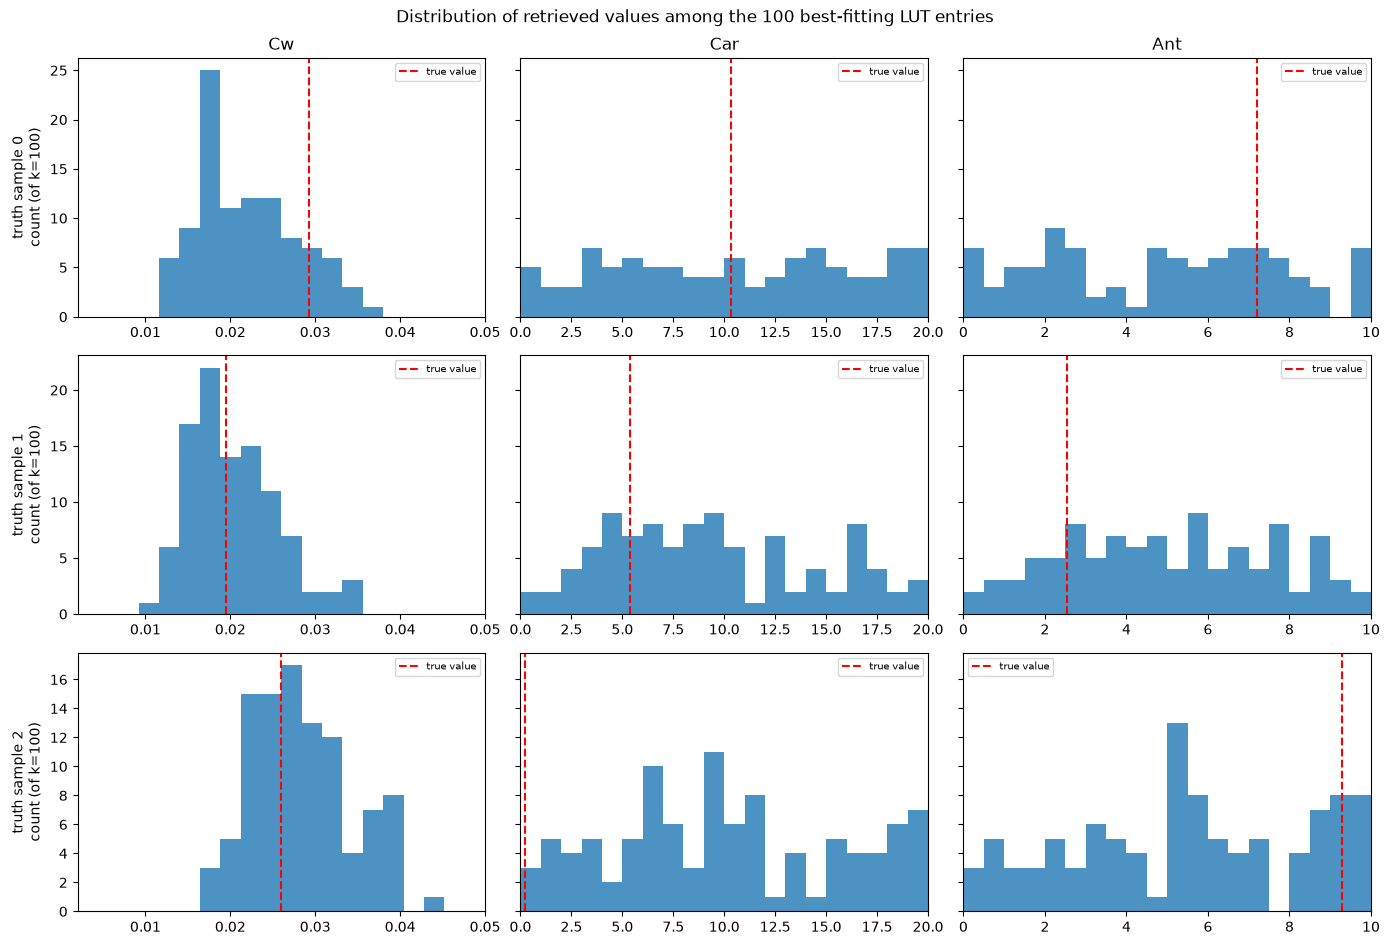

In [4]:
K_SHOW = 100
SAMPLE_IDX = [0, 1, 2]
kb100 = pi.k_best_retrieval(noisy_truth_spectra, reference_lut, k=K_SHOW, wavelength_mask=valid_bands)

fig, axes = plt.subplots(len(SAMPLE_IDX), 3, figsize=(14, 3.2 * len(SAMPLE_IDX)), sharey="row")
for row, sample_idx in enumerate(SAMPLE_IDX):
    for col, param in enumerate(["Cw", "Car", "Ant"]):
        j = param_names.index(param)
        lo, hi = pi.PARAMETER_RANGES[param]
        vals = kb100["topk_params"][sample_idx, :, j]
        true_val = true_params[sample_idx, j]
        ax = axes[row, col]
        ax.hist(vals, bins=20, range=(lo, hi), color="C0", alpha=0.8)
        ax.axvline(true_val, color="red", linestyle="--", label="true value")
        if row == 0:
            ax.set_title(param)
        if col == 0:
            ax.set_ylabel(f"truth sample {sample_idx}\ncount (of k={K_SHOW})")
        ax.set_xlim(lo, hi)
        ax.legend(fontsize=7)
plt.suptitle(f"Distribution of retrieved values among the {K_SHOW} best-fitting LUT entries")
plt.tight_layout()
plt.savefig("../results/figures/08_cost_valley_Cw_vs_CarAnt.png", dpi=150)
plt.show()

## k-best mean vs. single-NN — does averaging change the headline numbers?

In [5]:
from src import metrics

single_nn = pi.invert_lut_batch(noisy_truth_spectra, reference_lut, wavelength_mask=valid_bands)
k_best_mean = kb100["mean"]

rows = []
for j, name in enumerate(param_names):
    t = true_params[:, j]
    lo, hi = pi.PARAMETER_RANGES[name]
    rows.append({
        "parameter": name,
        "r_squared_single_nn": metrics.r_squared(t, single_nn[:, j]),
        "r_squared_k100_mean": metrics.r_squared(t, k_best_mean[:, j]),
    })
pd.DataFrame(rows).set_index("parameter")

,r_squared_single_nn,r_squared_k100_mean
parameter,,
N,0.167593,0.387980
Cab,0.855953,0.816582
Car,-0.464164,0.069575
Ant,0.043571,0.169352
Cw,0.869690,0.860673
Cm,0.682503,0.708644
LAI,0.489582,0.592869


## Next steps

Multi-scene generalisation (`08_multi_scene_generalisation.ipynb`) tests whether the Cw/SWIR result and the ill-posedness pattern replicate across additional Tanager scenes.